# Siparişler

✏️ **Alıştırma**

Bugün **siparişleri** ve bunlara ait **değerlendirme puanını (review score)** inceleyeceğiz.

👉 Amacımız aşağıdaki özelliklere sahip bir DataFrame oluşturmaktır:


| özellik_adı  	| tip  	| açıklama  	|
|:---	|:---:	|:---	|
| `order_id` 	| str 	| siparişin kimliği (id) 	|
| `wait_time` 	| float 	| `order_purchase_timestamp` ile `order_delivered_customer_date` arasındaki gün sayısı 	|
| `expected_wait_time` 	| float 	| `order_purchase_timestamp` ile `estimated_delivery_date` arasındaki beklenen gün sayısı 	|
| `delay_vs_expected` 	| float 	| gerçek `order_delivered_customer_date` tahmini teslim tarihinden sonra ise iki tarih arasındaki gün sayısını döndürür, aksi halde 0 döndürür 	|
| `order_status` 	| str 	| siparişin durumu 	|
| `dim_is_five_star` 	| int 	| sipariş beş yıldız aldıysa 1, aksi halde 0 	|
| `dim_is_one_star` 	| int 	| sipariş bir yıldız aldıysa 1, aksi halde 0 	|
| `review_score` 	| int 	| 1 ile 5 arasında 	|
| `number_of_items` 	| int 	| siparişin içerdiği toplam ürün sayısı 	|
| `number_of_sellers` 	| int 	| siparişte yer alan satıcı sayısı 	|
| `price` 	| float 	| müşterinin ödediği toplam sipariş fiyatı 	|
| `freight_value` 	| float 	| müşterinin ödediği kargo ücreti 	|
| `distance_customer_seller` 	| float 	| müşteri ile satıcı arasındaki mesafe (km, isteğe bağlı) 	|  

⚠️ Ayrıca "teslim edilmemiş" siparişleri filtrelemeliyiz; aksi belirtilmedikçe bunları dahil etmeyin, çünkü potansiyel gecikmeleri hesaplayamayız.

❓ **Senin görevin**: 

- Her bir özelliği `olist/order.py` içindeki `Order` sınıfında ayrı bir metod olarak uygulayın
- Ardından, eksiksiz DataFrame'i **`NaN` içermeyecek şekilde** döndüren `get_training_data()` metodunu oluşturun.

💡 Önerilen yöntem:
- Önce aşağıdaki notebook'u kullanarak kodunuzu adım adım yazıp test edin
- Kod mantığınızdan emin olduktan sonra kodu `order.py` dosyasına kopyalayın
- Şimdilik veri işleme mantığına odaklanın; veriyi görselleştirmeyi sonraki alıştırmalarda yapacağız

🔥 Notebook için en iyi uygulamalar (okumanız zorunludur) 👇

<details>
    <summary>▸ <i>tıklayın</i></summary>

Bundan sonra keşif amaçlı notebook'lar oldukça uzun olabilir; bu nedenle aşağıdaki ilkeleri takip etmenizi şiddetle tavsiye ediyoruz:
- Kodunuzu, Notebook her zaman baştan sona çalıştırıldığında çökmeden çalışacak şekilde yazın (Run --> Run All Cells)
- Değişken adlarını dikkatli seçin
- Kısa süreyle kullanılacak ara adımlar için `tmp` veya `_` gibi geçici isimler kullanın
- Notebook boyutunu azaltmak için kodunuzu temizleyin ve hücreleri birleştirin (`Shift-M`)
- Katlanabilir başlıklar ve içerik tablosunu sıkça kullanın (bulamazsanız bir TA'ya danışın)
- Aşağıdaki kısayolları kullanın
    - `a` bir hücre üstüne ekler
    - `b` bir hücre alta ekler
    - `dd` bir hücreyi siler
    - `esc` ve `ok` tuşları ile hücreler arası gezinme
    - `Shift-Enter` hücreyi çalıştırır ve sonraki hücreye geçer
    - parantez içindeyken örn. `groupby()` üzerinde `Shift + Tab` kullanarak dokümantasyona bakabilirsiniz. Birkaç kez tekrar edin, kalıcı olarak açmak için

</details>

In [35]:
# Auto reload imported module every time a jupyter cell is executed (handy for olist.order.py updates)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
# Import usual modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
%matplotlib inline

In [38]:
# Import olist data
from olist.data import Olist
olist = Olist()
data = olist.get_data()

In [39]:
# What datasets do we have access to now ?
data.keys()

dict_keys(['products', 'orders', 'sellers', 'geolocation', 'order_reviews', 'order_items', 'customers', 'order_payments', 'product_category_name_translation'])

In [40]:
orders = data['orders'].copy() # good practice to be sure not to modify your `data` variable

assert(orders.shape == (99441, 8))

## 1. `order.py` dosyasını kodlayın

### a) `get_wait_time`
    ❓ Aşağıyı döndüren bir DataFrame oluşturun:
           `order_id`, `wait_time`, `expected_wait_time`, `delay_vs_expected`, `order_status`



🎁 Bu ilk metod için aşağıda size pseudo-kod veriyoruz 👇

> 1. `orders` DataFrame'ini inceleyin
2. DataFrame'i `teslim edilmiş (delivered)` siparişler üzerine filtreleyin
3. `datetime` ile çalışmayı düzenleyin
    - Python [`datetime`](https://docs.python.org/3/library/datetime.html) nesnelerinin ne olduğunu anlamaya zaman ayırın
    - ve tarihleri "string" tipinden `pandas.to_datetime()` kullanarak `pandas.datetime` tipine dönüştürün
4. `order_purchase_timestamp`'tan başlayarak `wait_time`'ı gün cinsinden ondalıklı bir sayı olarak hesaplayın
5. `expected_wait_time`'ı `order_purchase_timestamp`'tan başlayarak gün cinsinden hesaplayın
6. `delay_vs_expected`'i gün cinsinden hesaplayın (sipariş tahmini teslim tarihinden daha erken teslim edildiyse 0 koyun)
7. Yeni DataFrame'i kontrol edin
8. Kodunuzdan memnun kaldığınızda, notebook'tan `olist/order.py`'ye dikkatlice kopyalayabilirsiniz
9. Şimdi metodunuzu `orders.py` içinde çağırmayı deneyin
10. Kodunuz muhtemelen hemen çalışmayacaktır
11. `.py` dosyası içinde çalışacak şekilde gerekli değişiklikleri yapın

`wait_time`, `expected_wait_time` ve `delay_vs_expected`'in tam sayı değil ondalıklı gün cinsinden olmasını istiyoruz. Düşünün: 8.1 veya 8.9 günlük bir bekleme büyük fark yaratır. Bu yüzden Pandas'ın `dt.day` özelliklerini kullanmayın; çünkü bu değerleri aşağı yuvarlar.

<details>
    <summary>💡İpucu</summary>

Hem `wait_time` hem de `delay_vs_expected` için ilgili tarihler arasındaki farkı almak üzere tarihleri çıkarmanız gerekir. Ardından bu farkın kaç günü temsil ettiğini bulmak için ya [`datetime.timedelta()`](https://docs.python.org/3/library/datetime.html#timedelta-objects) ya da [`np.timedelta64()`](https://numpy.org/doc/stable/reference/arrays.datetime.html#datetime-and-timedelta-arithmetic) kullanabilirsiniz!

</details>

In [41]:
orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


In [42]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [43]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [44]:
orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']

0        8 days 10:28:40
1       13 days 18:46:08
2        9 days 09:27:40
3       13 days 05:00:36
4        2 days 20:58:23
              ...       
99436    8 days 05:13:56
99437   22 days 04:38:58
99438   24 days 20:37:34
99439   17 days 02:04:27
99440    7 days 16:11:00
Length: 99441, dtype: timedelta64[ns]

In [45]:
import datetime
one_day_delta = datetime.timedelta(days=1)
one_day_delta = np.timedelta64(24, 'h')

orders.loc[:,'wait_time'] = \
    (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']) / one_day_delta

orders.loc[:,'delay_vs_expected'] = \
    (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']) / one_day_delta

orders.loc[:,'expected_wait_time'] = \
    (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']) / one_day_delta

In [46]:
(orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

0         8.0
1        13.0
2         9.0
3        13.0
4         2.0
         ... 
99436     8.0
99437    22.0
99438    24.0
99439    17.0
99440     7.0
Length: 99441, dtype: float64

In [47]:
def handle_delay(x):
    if x > 0:
        return x
    else:
        return 0

orders.loc[:,'delay_vs_expected'] = orders['delay_vs_expected'].apply(handle_delay)

In [48]:
orders[['order_id', 'wait_time', 'expected_wait_time', 'delay_vs_expected']]

,order_id,wait_time,expected_wait_time,delay_vs_expected
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,0.0
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,8.218009,18.587442,0.0
99437,63943bddc261676b46f01ca7ac2f7bd8,22.193727,23.459051,0.0
99438,83c1379a015df1e13d02aae0204711ab,24.859421,30.384225,0.0
99439,11c177c8e97725db2631073c19f07b62,17.086424,37.105243,0.0


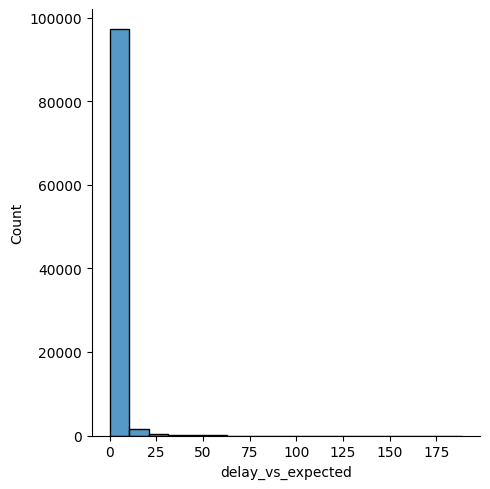

In [49]:
sns.displot(orders['delay_vs_expected'])

👀 Oluşturduğunuz DataFrame'i kontrol edin.  

💪 Kodunuz çalıştığında, kodunuzu `olist/order.py` içine taşıyın  

🧪 Şimdi aşağıdaki hücreyi çalıştırarak test edin 👇

In [50]:
# Test your code here
from olist.order import Order
Order().get_wait_time()

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0.0,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0.0,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0.0,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,0.0,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,0.0,delivered
...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,8.218009,18.587442,0.0,delivered
99437,63943bddc261676b46f01ca7ac2f7bd8,22.193727,23.459051,0.0,delivered
99438,83c1379a015df1e13d02aae0204711ab,24.859421,30.384225,0.0,delivered
99439,11c177c8e97725db2631073c19f07b62,17.086424,37.105243,0.0,delivered


In [51]:
import pandas as pd
import numpy as np
from olist.utils import haversine_distance
from olist.data import Olist


class Order:
    '''
    DataFrames containing all orders as index,
    and various properties of these orders as columns
    '''
    def __init__(self):
        # Assign an attribute ".data" to all new instances of Order
        self.data = Olist().get_data()

    def get_wait_time(self, is_delivered=True):
        """
        Returns a DataFrame with:
        [order_id, wait_time, expected_wait_time, delay_vs_expected, order_status]
        and filters out non-delivered orders unless specified
        """
        # Hint: Within this instance method, you have access to the instance of the class Order in the variable self, as well as all its attributes
        # $CHALLENGIFY_BEGIN
        # make sure to create a copy rather than a "view"
        orders = self.data['orders'].copy()

        # filter delivered orders
        if is_delivered:
            orders = orders.query("order_status=='delivered'").copy()

        # handle datetime
        orders.loc[:, 'order_delivered_customer_date'] = \
            pd.to_datetime(orders['order_delivered_customer_date'])
        orders.loc[:, 'order_estimated_delivery_date'] = \
            pd.to_datetime(orders['order_estimated_delivery_date'])
        orders.loc[:, 'order_purchase_timestamp'] = \
            pd.to_datetime(orders['order_purchase_timestamp'])

        # compute delay vs expected
        orders.loc[:, 'delay_vs_expected'] = \
            (orders['order_delivered_customer_date'] -
             orders['order_estimated_delivery_date']) / np.timedelta64(24, 'h')

        def handle_delay(x):
            # We only want to keep delay where wait_time is longer than expected (not the other way around)
            # This is what drives customer dissatisfaction!
            if x > 0:
                return x
            else:
                return 0

        orders.loc[:, 'delay_vs_expected'] = \
            orders['delay_vs_expected'].apply(handle_delay)

        # compute wait time
        orders.loc[:, 'wait_time'] = \
            (orders['order_delivered_customer_date'] -
             orders['order_purchase_timestamp']) / np.timedelta64(24, 'h')

        # compute expected wait time
        orders.loc[:, 'expected_wait_time'] = \
            (orders['order_estimated_delivery_date'] -
             orders['order_purchase_timestamp']) / np.timedelta64(24, 'h')

        return orders[[
            'order_id', 'wait_time', 'expected_wait_time', 'delay_vs_expected',
            'order_status'
        ]]
        # $CHALLENGIFY_END

    def get_review_score(self):
        """
        Returns a DataFrame with:
        order_id, dim_is_five_star, dim_is_one_star, review_score
        """
        # $CHALLENGIFY_BEGIN
        # import data
        reviews = self.data['order_reviews']

        def dim_five_star(d):
            if d == 5:
                return 1
            else:
                return 0

        def dim_one_star(d):
            if d == 1:
                return 1
            else:
                return 0

        reviews.loc[:, 'dim_is_five_star'] =\
            reviews['review_score'].apply(dim_five_star)

        reviews.loc[:, 'dim_is_one_star'] =\
            reviews['review_score'].apply(dim_one_star)

        return reviews[[
            'order_id', 'dim_is_five_star', 'dim_is_one_star', 'review_score'
        ]]
        # $CHALLENGIFY_END

    def get_number_items(self):
        """
        Returns a DataFrame with:
        order_id, number_of_items
        """
        # $CHALLENGIFY_BEGIN
        data = self.data
        items = \
            data['order_items']\
            .groupby('order_id',
                     as_index=False).agg({'order_item_id': 'count'})
        items.columns = ['order_id', 'number_of_items']
        return items
        # $CHALLENGIFY_END

    def get_number_sellers(self):
        """
        Returns a DataFrame with:
        order_id, number_of_sellers
        """
        # $CHALLENGIFY_BEGIN
        data = self.data
        sellers = \
            data['order_items']\
            .groupby('order_id')['seller_id'].nunique().reset_index()
        sellers.columns = ['order_id', 'number_of_sellers']

        return sellers
        # $CHALLENGIFY_END

    def get_price_and_freight(self):
        """
        Returns a DataFrame with:
        order_id, price, freight_value
        """
        # $CHALLENGIFY_BEGIN
        data = self.data
        price_freight = \
            data['order_items']\
            .groupby('order_id',
                     as_index=False).agg({'price': 'sum',
                                          'freight_value': 'sum'})

        return price_freight
        # $CHALLENGIFY_END

    # Optional
    def get_distance_seller_customer(self):
        """
        Returns a DataFrame with:
        order_id, distance_seller_customer
        """
        # $CHALLENGIFY_BEGIN

        # import data
        data = self.data
        orders = data['orders']
        order_items = data['order_items']
        sellers = data['sellers']
        customers = data['customers']

        # Since one zip code can map to multiple (lat, lng), take the first one
        geo = data['geolocation']
        geo = geo.groupby('geolocation_zip_code_prefix',
                          as_index=False).first()

        # Merge geo_location for sellers
        sellers_mask_columns = [
            'seller_id', 'seller_zip_code_prefix', 'geolocation_lat', 'geolocation_lng'
        ]

        sellers_geo = sellers.merge(
            geo,
            how='left',
            left_on='seller_zip_code_prefix',
            right_on='geolocation_zip_code_prefix')[sellers_mask_columns]

        # Merge geo_location for customers
        customers_mask_columns = ['customer_id', 'customer_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']

        customers_geo = customers.merge(
            geo,
            how='left',
            left_on='customer_zip_code_prefix',
            right_on='geolocation_zip_code_prefix')[customers_mask_columns]

        # Match customers with sellers in one table
        customers_sellers = customers.merge(orders, on='customer_id')\
            .merge(order_items, on='order_id')\
            .merge(sellers, on='seller_id')\
            [['order_id', 'customer_id','customer_zip_code_prefix', 'seller_id', 'seller_zip_code_prefix']]

        # Add the geoloc
        matching_geo = customers_sellers.merge(sellers_geo,
                                            on='seller_id')\
            .merge(customers_geo,
                   on='customer_id',
                   suffixes=('_seller',
                             '_customer'))
        # Remove na()
        matching_geo = matching_geo.dropna()

        matching_geo.loc[:, 'distance_seller_customer'] =\
            matching_geo.apply(lambda row:
                               haversine_distance(row['geolocation_lng_seller'],
                                                  row['geolocation_lat_seller'],
                                                  row['geolocation_lng_customer'],
                                                  row['geolocation_lat_customer']),
                               axis=1)
        # Since an order can have multiple sellers,
        # return the average of the distance per order
        order_distance =\
            matching_geo.groupby('order_id',
                                 as_index=False).agg({'distance_seller_customer':
                                                      'mean'})

        return order_distance
        # $CHALLENGIFY_END

    def get_training_data(self,
                          is_delivered=True,
                          with_distance_seller_customer=False):
        """
        Returns a clean DataFrame (without NaN), with the all following columns:
        ['order_id', 'wait_time', 'expected_wait_time', 'delay_vs_expected',
        'order_status', 'dim_is_five_star', 'dim_is_one_star', 'review_score',
        'number_of_items', 'number_of_sellers', 'price', 'freight_value',
        'distance_seller_customer']
        """
        # Hint: make sure to re-use your instance methods defined above
        # $CHALLENGIFY_BEGIN
        training_set =\
            self.get_wait_time(is_delivered)\
                .merge(
                self.get_review_score(), on='order_id'
            ).merge(
                self.get_number_items(), on='order_id'
            ).merge(
                self.get_number_sellers(), on='order_id'
            ).merge(
                self.get_price_and_freight(), on='order_id'
            )
        # Skip heavy computation of distance_seller_customer unless specified
        if with_distance_seller_customer:
            training_set = training_set.merge(
                self.get_distance_seller_customer(), on='order_id')

            return training_set.dropna()
            # $CHALLENGIFY_END


In [52]:
test_df = Order().get_wait_time()
print(test_df)

                               order_id  wait_time  expected_wait_time  \
0      e481f51cbdc54678b7cc49136f2d6af7   8.436574           15.544063   
1      53cdb2fc8bc7dce0b6741e2150273451  13.782037           19.137766   
2      47770eb9100c2d0c44946d9cf07ec65d   9.394213           26.639711   
3      949d5b44dbf5de918fe9c16f97b45f8a  13.208750           26.188819   
4      ad21c59c0840e6cb83a9ceb5573f8159   2.873877           12.112049   
...                                 ...        ...                 ...   
99436  9c5dedf39a927c1b2549525ed64a053c   8.218009           18.587442   
99437  63943bddc261676b46f01ca7ac2f7bd8  22.193727           23.459051   
99438  83c1379a015df1e13d02aae0204711ab  24.859421           30.384225   
99439  11c177c8e97725db2631073c19f07b62  17.086424           37.105243   
99440  66dea50a8b16d9b4dee7af250b4be1a5   7.674306           25.126736   

       delay_vs_expected order_status  
0                    0.0    delivered  
1                    0.0    del

In [53]:
from nbresult import ChallengeResult
test = Order().get_wait_time()
result = ChallengeResult('wait_time', dve_type=test["delay_vs_expected"].dtype, shape=test.shape, dve_min=test["delay_vs_expected"].min(), dve_max=test["delay_vs_expected"].max())
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/hamza/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /mnt/c/Users/Emmo/code/hamza-simsek/data-orders
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_wait_time.py::TestWaitTime::test_wait_time PASSED                   [100%]

============================== 1 passed in 0.86s ===============================


💯 You can commit your code:

git add tests/wait_time.pickle

git commit -m 'Completed wait_time step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### b) `get_review_score`
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `dim_is_five_star`, `dim_is_one_star`, `review_score`

`dim_is_$N$_star` sütunu `review_score=$N$` ise `1`, değilse `0` içermelidir

<details>
    <summary markdown='span'>İpuçları</summary>

`Series.map()` veya `DataFrame.apply()` üzerine düşünün
    
</details>

👉 We load the `reviews` for you

In [54]:
reviews = data['order_reviews'].copy()
assert(reviews.shape == (99224,7))
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [55]:
dim_is_one_star = lambda x: int(x==1)
dim_is_five_star = lambda x: int(x==5)

reviews["dim_is_five_star"] = reviews["review_score"].map(dim_is_five_star) # --> Series([0, 1, 1, 0, 0, 1 ...])
reviews["dim_is_one_star"] = reviews["review_score"].map(dim_is_one_star) # --> Series([0, 1, 1, 0, 0, 1 ...])

In [56]:
reviews[["order_id", "dim_is_five_star", "dim_is_one_star", "review_score"]]

,order_id,dim_is_five_star,dim_is_one_star,review_score
0,73fc7af87114b39712e6da79b0a377eb,0,0,4
1,a548910a1c6147796b98fdf73dbeba33,1,0,5
2,f9e4b658b201a9f2ecdecbb34bed034b,1,0,5
3,658677c97b385a9be170737859d3511b,1,0,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,1,0,5
...,...,...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,1,0,5
99220,22ec9f0669f784db00fa86d035cf8602,1,0,5
99221,55d4004744368f5571d1f590031933e4,1,0,5
99222,7725825d039fc1f0ceb7635e3f7d9206,0,0,4


Yine,

👀 Oluşturduğunuz DataFrame'i kontrol edin.  

💪 Kodunuz çalıştığında, kodunuzu `olist/order.py` içine taşıyın  

🧪 Şimdi aşağıdaki hücreyi çalıştırarak test edin 👇

In [57]:
# Test your code here
from olist.order import Order
Order().get_review_score()

,order_id,dim_is_five_star,dim_is_one_star,review_score
0,73fc7af87114b39712e6da79b0a377eb,0,0,4
1,a548910a1c6147796b98fdf73dbeba33,1,0,5
2,f9e4b658b201a9f2ecdecbb34bed034b,1,0,5
3,658677c97b385a9be170737859d3511b,1,0,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,1,0,5
...,...,...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,1,0,5
99220,22ec9f0669f784db00fa86d035cf8602,1,0,5
99221,55d4004744368f5571d1f590031933e4,1,0,5
99222,7725825d039fc1f0ceb7635e3f7d9206,0,0,4


In [58]:
test_df = Order().get_review_score()
print(test_df)

                               order_id  dim_is_five_star  dim_is_one_star  \
0      73fc7af87114b39712e6da79b0a377eb                 0                0   
1      a548910a1c6147796b98fdf73dbeba33                 1                0   
2      f9e4b658b201a9f2ecdecbb34bed034b                 1                0   
3      658677c97b385a9be170737859d3511b                 1                0   
4      8e6bfb81e283fa7e4f11123a3fb894f1                 1                0   
...                                 ...               ...              ...   
99219  2a8c23fee101d4d5662fa670396eb8da                 1                0   
99220  22ec9f0669f784db00fa86d035cf8602                 1                0   
99221  55d4004744368f5571d1f590031933e4                 1                0   
99222  7725825d039fc1f0ceb7635e3f7d9206                 0                0   
99223  90531360ecb1eec2a1fbb265a0db0508                 0                1   

       review_score  
0                 4  
1                 5

In [59]:
from nbresult import ChallengeResult
result = ChallengeResult('review_score', shape=Order().get_review_score().shape)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/hamza/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /mnt/c/Users/Emmo/code/hamza-simsek/data-orders
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_review_score.py::TestReviewScore::test_review_score PASSED          [100%]

============================== 1 passed in -0.19s ==============================


💯 You can commit your code:

git add tests/review_score.pickle

git commit -m 'Completed review_score step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### c) `get_number_items`:
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `number_of_items` (her sipariş için toplam ürün sayısı)

In [60]:
data["order_items"].groupby("order_id").count()\
.rename(columns={"order_item_id": "number_of_items"})\
.sort_values("number_of_items")[['number_of_items']]

,number_of_items
order_id,
00010242fe8c5a6d1ba2dd792cb16214,1
a6e9d106235bcf1dda54253686d89e99,1
a6e9b80a7636eb8dd592dbb3e20d0a91,1
a6e963c11e80432334e984ead4797a8b,1
a6e8ad5db31e71f5f12671af561acb4a,1
...,...
428a2f660dc84138d969ccd69a0ab6d5,15
9ef13efd6949e4573a18964dd1bbe7f5,15
1b15974a0141d54e36626dca3fdc731a,20


🧪 Aynı rutin:
* DataFrame'inizi kontrol edin,
* Kodunuzu `olist/order.py` içine taşıyın
* ve gerçekten çalıştığını doğrulayın.

In [61]:
from nbresult import ChallengeResult
result = ChallengeResult('number_items',
                         shape=Order().get_number_items().shape,
                         columns=Order().get_number_items().columns)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/hamza/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /mnt/c/Users/Emmo/code/hamza-simsek/data-orders
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_number_items.py::TestNumberItems::test_column_names PASSED          [ 50%]
test_number_items.py::TestNumberItems::test_number_items PASSED          [100%]

============================== 2 passed in 1.31s ===============================


💯 You can commit your code:

git add tests/number_items.pickle

git commit -m 'Completed number_items step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### d) `get_number_sellers`:
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `number_of_sellers` (her sipariş için benzersiz satıcı sayısı)
        
<details>
    <summary>▸ <i>İpucu</i></summary>

`pd.Series.nunique()` metoduna bakın
</details>

In [62]:
sellers = \
    data['order_items']\
    .groupby('order_id')['seller_id'].nunique().reset_index()

sellers.columns = ['order_id', 'number_of_sellers']
sellers.sort_values('number_of_sellers')

,order_id,number_of_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1
65559,aaaf314a8cf0d0da71e52c6cd4184cbd,1
65558,aaaea350ff8a957595f3c631d6b63d1b,1
65557,aaae80f5b6239bd9e1b22e9aa542c3e8,1
65556,aaabf43feb9498d9de4588eb73231c25,1
...,...,...
11231,1d23106803c48c391366ff224513fb7f,4
53796,8c2b13adf3f377c8f2b06b04321b0925,4
55847,91be51c856a90d7efe86cf9d082d6ae3,4
79967,cf5c8d9f52807cb2d2f0a0ff54c478da,5


In [63]:
Order().get_number_sellers()

,order_id,number_of_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,1
98662,fffcd46ef2263f404302a634eb57f7eb,1
98663,fffce4705a9662cd70adb13d4a31832d,1
98664,fffe18544ffabc95dfada21779c9644f,1


In [64]:
from nbresult import ChallengeResult
result = ChallengeResult('number_sellers',
                         shape=Order().get_number_sellers().shape,
                         columns=Order().get_number_sellers().columns)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/hamza/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /mnt/c/Users/Emmo/code/hamza-simsek/data-orders
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_number_sellers.py::TestNumberSellers::test_column_names PASSED      [ 50%]
test_number_sellers.py::TestNumberSellers::test_number_seller PASSED     [100%]

============================== 2 passed in 1.23s ===============================


💯 You can commit your code:

git add tests/number_sellers.pickle

git commit -m 'Completed number_sellers step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### e) `get_price_and_freight`
     Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `price`, `freight_value`

In [65]:
price_freight = \
    data['order_items']\
    .groupby('order_id',
             as_index=False).agg({'price': 'sum',
                                  'freight_value': 'sum'})
price_freight

,order_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14
...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99,43.41
98662,fffcd46ef2263f404302a634eb57f7eb,350.00,36.53
98663,fffce4705a9662cd70adb13d4a31832d,99.90,16.95
98664,fffe18544ffabc95dfada21779c9644f,55.99,8.72


In [66]:
from nbresult import ChallengeResult
result = ChallengeResult('price', shape=Order().get_price_and_freight().shape)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/hamza/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /mnt/c/Users/Emmo/code/hamza-simsek/data-orders
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_price.py::TestPrice::test_price PASSED                              [100%]

============================== 1 passed in 0.22s ===============================


💯 You can commit your code:

git add tests/price.pickle

git commit -m 'Completed price step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

## 2. Hepsini bir arada: `get_training_data`

❓ Daha önce kodladığınız metodları kullanarak `get_training_data` metodunu yazma zamanı; tüm sipariş özelliklerini tek bir tabloda toplayın.

In [67]:
# YOUR CODE HERE

🧪 Aşağıda test edin

In [71]:
from nbresult import ChallengeResult
from olist.order import Order
data = Order().get_training_data()

result = ChallengeResult('training',
    shape=data.shape,
    columns=sorted(list(data.columns))
)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/hamza/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /mnt/c/Users/Emmo/code/hamza-simsek/data-orders
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_training.py::TestTraining::test_training_data_columns PASSED        [ 50%]
test_training.py::TestTraining::test_training_data_shape PASSED          [100%]

============================== 2 passed in 0.19s ===============================


💯 You can commit your code:

git add tests/training.pickle

git commit -m 'Completed training step'

git push origin master



💡 **Beklenen satır sayısını elde edemiyor musunuz?**
<details><summary>8 satırlık bir fark mı var?</summary>
Sonuçta `NaN` içermeyen bir DataFrame istiyoruz. `NaN`'ları kaldırmayı deneyin. (Çok karmaşık hale getirmeyin: genelde kodunuzda bir satırı değiştirmeniz yeterlidir.)
</details>
<details><summary>Başka bir fark mı var?</summary>
Belki tüm adımları tek bir DataFrame'de birleştirirken bir şey yanlış gitmiştir? Birleştirmelerinizi (merge) kontrol edin.
</details>

🏁 Tebrikler! 

💾 Notebook'unuzu ve `olist/order.py` içindeki kodunuzu commit edip pushlayın, sonra sonraki alıştırmaya geçin.

## 3. [İSTEĞE BAĞLI] `get_distance_seller_customer` 
**Bu fonksiyonu yalnızca bugünkü alıştırmaları bitirdikten sonra yazmayı deneyin.**

**Önce bir sonraki alıştırmaya geçin.**

    ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `distance_seller_customer` (müşteri ile satıcı arasındaki mesafe, km cinsinden)

💡 `olist.utils` modülünde sizin için yazılmış `haversine_distance` formülüne göz atın

Bunu kullanarak `get_distance_seller_customer`'ı kodlayın.

⚠️ Bir sipariş birden fazla satıcı içerebileceği için, sipariş başına ortalama satıcı-müşteri mesafesini alın.

In [ ]:
# YOUR CODE HERE

In [ ]:
matching_geo = Order().get_distance_seller_customer()

👉 Hemen satıcı-müşteri mesafesinin dağılımını hızlıca inceleyelim :)

In [ ]:
sns.displot(data = matching_geo, x ='distance_seller_customer')

👉 Satıcı-müşteri mesafesinin medyanı ve ortalaması nedir?

In [ ]:
matching_geo['distance_seller_customer'].describe()

👀 Yeni DataFrame'inizi kontrol edin ve kod çalıştığında `olist/order.py` içine taşıyın.

In [ ]:
Order().get_distance_seller_customer()['distance_seller_customer']

🧪 Kodunuzu test edin

In [72]:
from nbresult import ChallengeResult

result = ChallengeResult('distance',
    mean = Order().get_distance_seller_customer()['distance_seller_customer'].mean())
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/hamza/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /mnt/c/Users/Emmo/code/hamza-simsek/data-orders
configfile: pytest.ini
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_distance.py::TestDistance::test_distance PASSED                     [100%]

============================== 1 passed in 0.43s ===============================


💯 You can commit your code:

git add tests/distance.pickle

git commit -m 'Completed distance step'

git push origin master



Ayrıca `with_distance_seller_customer` `True` olarak ayarlandığında `get_training_data`'yı `get_distance_seller_customer` ile birleştirecek şekilde güncelleyin.

⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!